# medical insurance policies


In [1]:
# # Import libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer


In [2]:
# # Load Data
# df = pd.read_csv('insurance.csv')

In [3]:
# # --- DATA PREPROCESSING ---
# # Checking for missing values
# print(df.isnull().sum())


In [4]:
# # One-Hot Encoding for categorical variables
# df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [5]:
# # Splitting Data
# X = df.drop('charges', axis=1)
# y = df['charges']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# # Feature Scaling (Standardization)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [7]:
# # --- MODEL BUILDING ---
# # Initialize models
# lr_model = LinearRegression()
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


In [8]:
# # Train models
# lr_model.fit(X_train_scaled, y_train)
# rf_model.fit(X_train_scaled, y_train)

In [9]:
# # Predictions
# y_pred_lr = lr_model.predict(X_test_scaled)
# y_pred_rf = rf_model.predict(X_test_scaled)


In [10]:
# #MODEL EVALUATION
# def evaluate_model(y_true, y_pred, model_name):
#     print(f"--- {model_name} Results ---")
#     print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
#     print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
#     print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}\n")

# evaluate_model(y_test, y_pred_lr, "Linear Regression")
# evaluate_model(y_test, y_pred_rf, "Random Forest")

In [11]:
# #Visualize Results (Optional)
# plt.scatter(y_test, y_pred_rf)
# plt.xlabel("Actual Charges")
# plt.ylabel("Predicted Charges")
# plt.title("Actual vs Predicted Charges (Random Forest)")
# plt.show()


# Actual Answer question 4

# Medical Insurance Premium Prediction 

In [13]:
#Import Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.preprocessing import LabelEncoder 
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [15]:
#Load Dataset 
df = pd.read_csv("insurance.csv")  # dataset file 

In [17]:
#First 5 rows 
df.head() 

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
#Dataset shape 
df.shape 

(1338, 8)

In [19]:
#Missing values 
df.isnull().sum() 

index       0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
#Statistical summary 
df.describe()

,index,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,668.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,0.000000,18.000000,15.960000,0.000000,1121.873900
25%,334.250000,27.000000,26.296250,0.000000,4740.287150
50%,668.500000,39.000000,30.400000,1.000000,9382.033000
75%,1002.750000,51.000000,34.693750,2.000000,16639.912515
max,1337.000000,64.000000,53.130000,5.000000,63770.428010


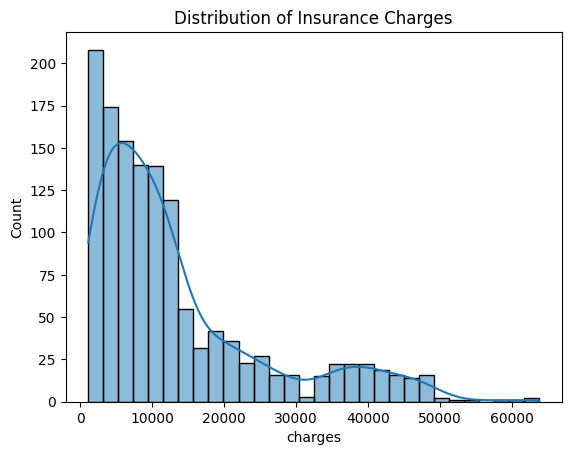

In [21]:
#Data Visualization 
#Distribution of Premium Charges 
plt.figure() 
sns.histplot(df['charges'], kde=True) 
plt.title("Distribution of Insurance Charges") 
plt.show() 

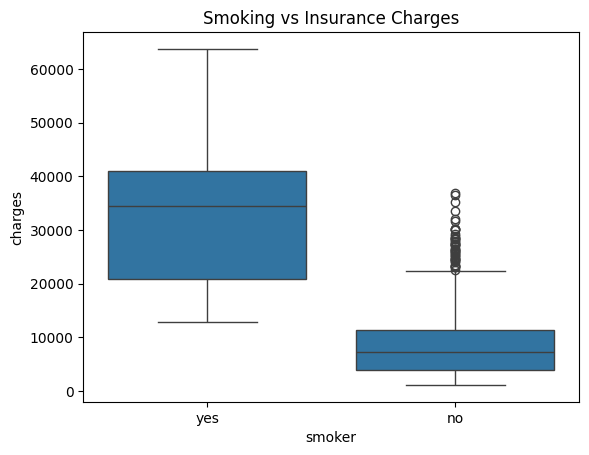

In [22]:
#Smoking vs Charges 
plt.figure() 
sns.boxplot(x='smoker', y='charges', data=df) 
plt.title("Smoking vs Insurance Charges") 
plt.show() 

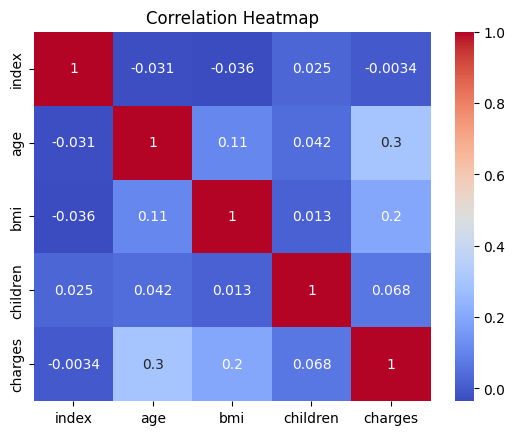

In [23]:
#CORRELATION Heatmap 
plt.figure() 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm') 
plt.title("Correlation Heatmap") 
plt.show() 

In [25]:
#Encoding Categorical Variables 
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) 
df['smoker'] = le.fit_transform(df['smoker']) 
df['region'] = le.fit_transform(df['region']) 

In [26]:
#Feature Selection 
X = df.drop('charges', axis=1) 
y = df['charges']

In [27]:
#Train-Test Split (70-30) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42 )

In [29]:
#Train Models 
#Linear Regression 
lr = LinearRegression() 
lr.fit(X_train, y_train) 
lr_pred = lr.predict(X_test) 


In [30]:
#Decision Tree 
dt = DecisionTreeRegressor() 
dt.fit(X_train, y_train) 
dt_pred = dt.predict(X_test)

In [31]:
#Random Forest 
rf = RandomForestRegressor() 
rf.fit(X_train, y_train) 
rf_pred = rf.predict(X_test)

In [32]:
#Evaluation Function 
def evaluate(y_test, y_pred): 
    mae = mean_absolute_error(y_test, y_pred) 
    mse = mean_squared_error(y_test, y_pred) 
    rmse = np.sqrt(mse) 
    r2 = r2_score(y_test, y_pred) 
    return mae, mse, rmse, r2

In [33]:
#Compare Models 
results = pd.DataFrame({ 
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"], 
    "MAE": [ 
        evaluate(y_test, lr_pred)[0], 
        evaluate(y_test, dt_pred)[0], 
        evaluate(y_test, rf_pred)[0] 
    ], 
    "MSE": [ 
        evaluate(y_test, lr_pred)[1], 
        evaluate(y_test, dt_pred)[1], 
        evaluate(y_test, rf_pred)[1] 
    ], 
    "RMSE": [ 
        evaluate(y_test, lr_pred)[2], 
        evaluate(y_test, dt_pred)[2], 
        evaluate(y_test, rf_pred)[2] 
    ], 
    "R2 Score": [ 
        evaluate(y_test, lr_pred)[3], 
        evaluate(y_test, dt_pred)[3], 
        evaluate(y_test, rf_pred)[3] 
    ] 
}) 
 
print(results)

               Model          MAE           MSE         RMSE  R2 Score
0  Linear Regression  4165.876529  3.398724e+07  5829.857356  0.768202
1      Decision Tree  3219.831841  4.456519e+07  6675.716373  0.696059
2      Random Forest  2698.107211  2.188675e+07  4678.327570  0.850729


In [34]:
#Hyperparameter Tuning 
#GridSearchCV for Random Forest 
param_grid = { 
    'n_estimators': [50, 100], 
    'max_depth': [None, 10, 20], 
    'min_samples_split': [2, 5] 
} 
 
grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=5) 
grid.fit(X_train, y_train) 
 
best_model = grid.best_estimator_ 

In [35]:
#Evaluate Tuned Model 
best_pred = best_model.predict(X_test) 
print("Tuned Model:", evaluate(y_test, best_pred)) 

Tuned Model: (2635.3493969432525, 21046849.461114056, np.float64(4587.684542458653), 0.8564572971330819)


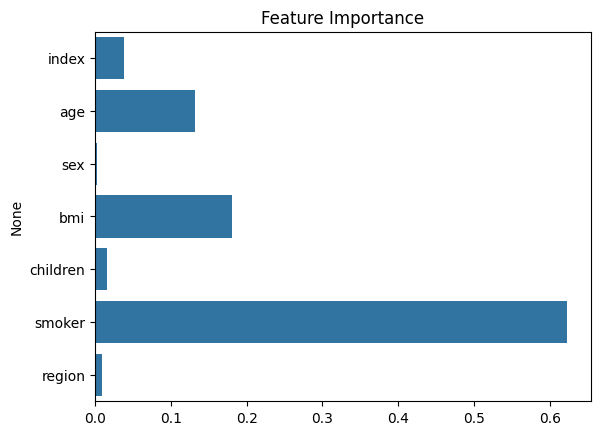

In [36]:
#Feature Importance 
importance = best_model.feature_importances_ 
 
plt.figure() 
sns.barplot(x=importance, y=X.columns) 
plt.title("Feature Importance") 
plt.show()

In [39]:
#Prediction Function 
def predict_premium(age, bmi, smoker, children, region): 
    # Encoding inputs 
    smoker = 1 if smoker.lower() == 'yes' else 0 
    region_dict = {'northeast':0, 'northwest':1, 'southeast':2, 'southwest':3} 
    region = region_dict[region.lower()] 
    input_data = np.array([[age, 0, bmi, children, smoker, region]]) 
    return best_model.predict(input_data)[0] 
# Example 
#print(predict_premium(30, 25.5, 'yes', 2, 'southwest'))